**Task 1 : initial inspection on data**

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/accepted_2007_to_2018Q4.csv')
data.head(5)

/tmp/ipython-input-2040800617.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/accepted_2007_to_2018Q4.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


only taking the first 10000 rows for entire analysis

In [ ]:
df = data.sample(n=10000) # considering only 10000 rows

In [ ]:
data.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('O')], dtype=object)

In [ ]:
data.dtypes

,0
id,int64
member_id,float64
loan_amnt,float64
funded_amnt,float64
funded_amnt_inv,float64
...,...
settlement_status,object
settlement_date,object
settlement_amount,float64
settlement_percentage,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 10272 to 23881
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 11.6+ MB


In [ ]:
df.shape

(10000, 151)

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,10000.0,6.642103e+07,1.988373e+06,614874.00,6.569672e+07,6.641308e+07,6.734874e+07,68616825.00
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,10000.0,1.497891e+04,8.613347e+03,1000.00,8.000000e+03,1.366250e+04,2.000000e+04,35000.00
funded_amnt,10000.0,1.497891e+04,8.613347e+03,1000.00,8.000000e+03,1.366250e+04,2.000000e+04,35000.00
funded_amnt_inv,10000.0,1.497119e+04,8.608405e+03,1000.00,8.000000e+03,1.365000e+04,2.000000e+04,35000.00
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,72.0,1.036117e+04,5.324568e+03,1231.17,6.078283e+03,1.049217e+04,1.519992e+04,22507.18
hardship_last_payment_amount,72.0,1.717146e+02,1.690299e+02,0.05,4.569500e+01,1.389500e+02,2.314400e+02,926.41
settlement_amount,275.0,4.578873e+03,3.339186e+03,186.00,1.917820e+03,3.648350e+03,6.601315e+03,15649.00
settlement_percentage,275.0,4.693975e+01,4.932390e+00,30.00,4.500000e+01,4.500000e+01,5.000000e+01,70.73


data has 151 columns and 10000 data entries.

In [ ]:
# missing value analysis
df.isnull().sum()

,0
id,0
member_id,10000
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
...,...
settlement_status,9725
settlement_date,9725
settlement_amount,9725
settlement_percentage,9725


In [ ]:
columns=df.columns
columns[0:]

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

# **Data Preprocessing and Cleaning**

1. **Missing value analysis** :

computing for missing percentage for each column

In [ ]:
missing_count=df.isnull().sum()
missing_percentage=(missing_count/len(df))*100
df1 = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_percentage})
df1=df1.sort_values(by='Missing Percentage', ascending=False)
df1

,Missing Count,Missing Percentage
member_id,10000,100.0
desc,10000,100.0
sec_app_open_act_il,10000,100.0
sec_app_inq_last_6mths,10000,100.0
sec_app_open_acc,10000,100.0
...,...,...
last_pymnt_amnt,0,0.0
last_credit_pull_d,0,0.0
collections_12_mths_ex_med,0,0.0
last_fico_range_low,0,0.0


 ignoring all the columns which has missing value percent above 40%.

In [ ]:
T = 40

# Identify columns to drop based on the threshold
drop_col = df1[df1['Missing Percentage'] > T].index.tolist()

print(f"Original DataFrame shape: {df1.shape}")
print(f"Columns to be dropped ({len(drop_col)}):\n{drop_col}")

# Drop the identified columns from the DataFrame
df_cleaned = df.drop(columns=drop_col)

print(f"New DataFrame shape after dropping columns: {df_cleaned.shape}")

Original DataFrame shape: (151, 2)
Columns to be dropped (58):
['member_id', 'desc', 'sec_app_open_act_il', 'sec_app_inq_last_6mths', 'sec_app_open_acc', 'sec_app_mort_acc', 'sec_app_mths_since_last_major_derog', 'sec_app_collections_12_mths_ex_med', 'sec_app_chargeoff_within_12_mths', 'sec_app_num_rev_accts', 'sec_app_earliest_cr_line', 'sec_app_revol_util', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'revol_bal_joint', 'dti_joint', 'verification_status_joint', 'annual_inc_joint', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date', 'hardship_reason', 'hardship_type', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_length', 'hardship_status', 'hardship_start_date', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'hardship_loan_status', 'deferral_term', 'settlement_percentage', 'settlement_amount', 'settlement_term', 'settlement_status', 'debt_settlement_flag_date', 'settlement_date', 'next_pymnt_d', 'mths_since_last_reco

after filteriing out , now the dataset has 10000 rows and 93 columns.

In [ ]:
df = df_cleaned
df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
10272,67908464,19600.0,19600.0,19600.0,60 months,14.48,460.95,C,C5,Aircraft Tech Inspector,...,20.0,0.0,0.0,54349.0,37555.0,9200.0,11949.0,N,Cash,N
19509,67465867,25000.0,25000.0,25000.0,36 months,5.32,752.87,A,A1,Dean,...,41.2,0.0,0.0,518468.0,166387.0,85000.0,191268.0,N,Cash,N
30915,66611766,12000.0,12000.0,12000.0,36 months,8.38,378.15,B,B1,Director,...,0.0,0.0,0.0,280600.0,201127.0,51300.0,109400.0,N,Cash,N
15,68354783,9600.0,9600.0,9600.0,36 months,7.49,298.58,A,A4,tech,...,66.7,0.0,0.0,88635.0,55387.0,12500.0,75635.0,N,Cash,N
9793,67948855,16500.0,16500.0,16500.0,36 months,11.22,541.91,B,B5,staff Rn,...,20.0,0.0,0.0,201003.0,31954.0,33400.0,21651.0,N,Cash,N


In [ ]:
df.shape

(10000, 93)

re-examine the output of df.isna().sum() to confirm that all missing values have been handled.

In [ ]:
df.isnull().sum()

,0
id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
...,...
total_bc_limit,1
total_il_high_credit_limit,1
hardship_flag,1
disbursement_method,1


checking the data set for any duplicate rows.

In [ ]:
if df.duplicated().any():
    print("Duplicate rows found in the DataFrame.")
else :
    print("no dulplicates found")

no dulplicates found


It is found that there are no duplicates within df

2. **Data Categorization** :

In [ ]:
cat_columns = df.select_dtypes(include=['object']).columns.tolist()
num_columns = df.select_dtypes(exclude=['object']).columns.tolist()
datetime_columns = df.select_dtypes(include=['datetime64']).columns.tolist()

In [ ]:
print("number of catergorical columns:",len(cat_columns))
print("number of numerical columns:",len(num_columns))

number of catergorical columns: 23
number of numerical columns: 70


there is 23 categorical columns and 70 numerical columns.

In [ ]:
df = df.reset_index(drop = True)

using simple impute to fill in the missing columns with central tendencies.

for numerical values, i am using median as the filling strategy.

In [ ]:
from sklearn.impute import SimpleImputer

numerical_cols_with_missing = []
for col in num_columns:
    if df[col].isnull().any():
        numerical_cols_with_missing.append(col)
print("Count of Missing values column : ",len(numerical_cols_with_missing))
print(f"Columns to be imputed : {numerical_cols_with_missing}")

Count of Missing values column :  37
Columns to be imputed : ['revol_util', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']


There are 9 columns with missing values in the numerical columns.

In [ ]:
if numerical_cols_with_missing:
    imputer_numerical = SimpleImputer(strategy='median')
    df[numerical_cols_with_missing] = imputer_numerical.fit_transform(df[numerical_cols_with_missing])
    print("\nImputation complete for numerical columns using SimpleImputer (median strategy).")
else:
    print("\nNo numerical columns with missing values found for imputation.")

# Verify that missing values have been handled for these columns
print("\nMissing values after SimpleImputer numerical imputation:")
print(df[numerical_cols_with_missing].isnull().sum())


Imputation complete for numerical columns using SimpleImputer (median strategy).

Missing values after SimpleImputer numerical imputation:
revol_util                    0
total_rev_hi_lim              0
acc_open_past_24mths          0
avg_cur_bal                   0
bc_open_to_buy                0
bc_util                       0
chargeoff_within_12_mths      0
delinq_amnt                   0
mo_sin_old_il_acct            0
mo_sin_old_rev_tl_op          0
mo_sin_rcnt_rev_tl_op         0
mo_sin_rcnt_tl                0
mort_acc                      0
mths_since_recent_bc          0
mths_since_recent_inq         0
num_accts_ever_120_pd         0
num_actv_bc_tl                0
num_actv_rev_tl               0
num_bc_sats                   0
num_bc_tl                     0
num_il_tl                     0
num_op_rev_tl                 0
num_rev_accts                 0
num_rev_tl_bal_gt_0           0
num_sats                      0
num_tl_120dpd_2m              0
num_tl_30dpd                

checking missing values in categorical columns if so using most frequent strategy to impute.

In [ ]:
categorical_cols_with_missing = []
for col in cat_columns:
    if df[col].isnull().any():
        categorical_cols_with_missing.append(col)
print("Count of Missing values column : ",len(categorical_cols_with_missing))
print(f"Columns to be imputed : {categorical_cols_with_missing}")

Count of Missing values column :  7
Columns to be imputed : ['emp_title', 'emp_length', 'title', 'last_pymnt_d', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']


there is 4 categorical columns with missing values

In [ ]:
if categorical_cols_with_missing:
    imputer_categorical= SimpleImputer(strategy='most_frequent')
    df[categorical_cols_with_missing] = imputer_categorical.fit_transform(df[categorical_cols_with_missing])
    print("\nImputation complete for categorical columns using SimpleImputer (most_frequent strategy).")
else:
    print("\nNo categorical columns with missing values found for imputation.")

# Verify that missing values have been handled for these columns
print("\nMissing values after SimpleImputer numerical imputation:")
print(df[categorical_cols_with_missing].isnull().sum())


Imputation complete for categorical columns using SimpleImputer (most_frequent strategy).

Missing values after SimpleImputer numerical imputation:
emp_title               0
emp_length              0
title                   0
last_pymnt_d            0
hardship_flag           0
disbursement_method     0
debt_settlement_flag    0
dtype: int64


*Q> Provide a detailed 1 − 2 paragraph rationale for the imputation methods chosen for at least three different columns.*

After removing columns with more than 40% of missing values, some numerical and categorical columns still had missing entries. For these, I used the SimpleImputer from sklearn.impute with a 'median' strategy and " most strategy.

*   column name :revol_util

The median was used because this is a financial variable and median imputation avoid unstable values (outliers) which can be added if mean was used creating skewness in data.

*   Column name : mths_since_recent_inq

Using the median preserves the natural pattern of 12 months , if mean used any other value can some like 13th or 5.5th months which is not in real life.

*  For categorical columns, the most frequent value is used. Mode imputation fills missing labels with the most common and representative category value within the columns.





After removing columns with a high percentage of missing values, some numerical columns still contained missing entries. For these, I employed the SimpleImputer from sklearn.impute with a 'median' strategy.

3. Data Transformation

In [ ]:
df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,67908464,19600.0,19600.0,19600.0,60 months,14.48,460.95,C,C5,Aircraft Tech Inspector,...,20.0,0.0,0.0,54349.0,37555.0,9200.0,11949.0,N,Cash,N
1,67465867,25000.0,25000.0,25000.0,36 months,5.32,752.87,A,A1,Dean,...,41.2,0.0,0.0,518468.0,166387.0,85000.0,191268.0,N,Cash,N
2,66611766,12000.0,12000.0,12000.0,36 months,8.38,378.15,B,B1,Director,...,0.0,0.0,0.0,280600.0,201127.0,51300.0,109400.0,N,Cash,N
3,68354783,9600.0,9600.0,9600.0,36 months,7.49,298.58,A,A4,tech,...,66.7,0.0,0.0,88635.0,55387.0,12500.0,75635.0,N,Cash,N
4,67948855,16500.0,16500.0,16500.0,36 months,11.22,541.91,B,B5,staff Rn,...,20.0,0.0,0.0,201003.0,31954.0,33400.0,21651.0,N,Cash,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 93 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   loan_amnt                   10000 non-null  float64
 2   funded_amnt                 10000 non-null  float64
 3   funded_amnt_inv             10000 non-null  float64
 4   term                        10000 non-null  object 
 5   int_rate                    10000 non-null  float64
 6   installment                 10000 non-null  float64
 7   grade                       10000 non-null  object 
 8   sub_grade                   10000 non-null  object 
 9   emp_title                   10000 non-null  object 
 10  emp_length                  10000 non-null  object 
 11  home_ownership              10000 non-null  object 
 12  annual_inc                  10000 non-null  float64
 13  verification_status         1000

In [ ]:
object_columns = df.select_dtypes(include='object').columns.tolist()
print("Object columns:", object_columns)


Object columns: ['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'last_pymnt_d', 'last_credit_pull_d', 'application_type', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']


In [ ]:
def clean_numeric_strings(series):
    series = series.astype(str)
    series = series.str.replace('%', '', regex=False)
    series = series.str.replace(',', '', regex=False)
    series = series.str.replace('₹', '', regex=False)
    series = series.str.replace('$', '', regex=False)
    return pd.to_numeric(series, errors='coerce')

for col in object_columns:
    cleaned = clean_numeric_strings(df[col])
    if cleaned.notna().sum() > 0.5 * len(df):  # convert only if >50% numeric
        df[col] = cleaned


convert_term_to_int_code

Convert a column like "36 months" → 36, "60 months" → 60

In [ ]:
# Convert 'term' column from '36 months' -> 36
df['term'] = (
    df['term']
    .astype(str)
    .str.extract(r'(\d+)')   # Extract digits
    .astype(float)           # Convert to float/int
    .astype('Int64')         # Nullable integer
)


convert_emp_length_to_int_code

Handles values like:

"< 1 year" → 0

"1 year" → 1

"10+ years" → 10

"3 years" → 3

"n/a" or missing → NaN

In [ ]:
def emp_length_to_int(x):
    x = str(x).lower().strip()

    if x == 'nan' or x == 'n/a':
        return None
    if '< 1 year' in x:
        return 0
    if '10+' in x:
        return 10

    # Extract digits from strings like '3 years'
    num = ''.join([ch for ch in x if ch.isdigit()])

    return int(num) if num else None

df['emp_length'] = df['emp_length'].apply(emp_length_to_int).astype('Int64')


In [ ]:
df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,67908464,19600.0,19600.0,19600.0,60,14.48,460.95,C,C5,Aircraft Tech Inspector,...,20.0,0.0,0.0,54349.0,37555.0,9200.0,11949.0,N,Cash,N
1,67465867,25000.0,25000.0,25000.0,36,5.32,752.87,A,A1,Dean,...,41.2,0.0,0.0,518468.0,166387.0,85000.0,191268.0,N,Cash,N
2,66611766,12000.0,12000.0,12000.0,36,8.38,378.15,B,B1,Director,...,0.0,0.0,0.0,280600.0,201127.0,51300.0,109400.0,N,Cash,N
3,68354783,9600.0,9600.0,9600.0,36,7.49,298.58,A,A4,tech,...,66.7,0.0,0.0,88635.0,55387.0,12500.0,75635.0,N,Cash,N
4,67948855,16500.0,16500.0,16500.0,36,11.22,541.91,B,B5,staff Rn,...,20.0,0.0,0.0,201003.0,31954.0,33400.0,21651.0,N,Cash,N


Feature Engineering (Dates): Extract a new, meaningful feature from a date column
(e.g., ’Loan Issue Month’ or ’Loan Term in Years’).

In [ ]:
# Convert to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'])

# Generate new features
df['issue_month'] = df['issue_d'].dt.month_name()
df['issue_month_num'] = df['issue_d'].dt.month
df['issue_year'] = df['issue_d'].dt.year
df['issue_quarter'] = df['issue_d'].dt.quarter

# Loan Term in Years (assuming term is numeric months)
df['loan_term_years'] = df['term'] / 12


/tmp/ipython-input-1351662007.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])


In [ ]:
print(df[['issue_d','issue_month','issue_year','loan_term_years']])

        issue_d issue_month  issue_year  loan_term_years
0    2015-12-01    December        2015              5.0
1    2015-12-01    December        2015              3.0
2    2015-12-01    December        2015              3.0
3    2015-12-01    December        2015              3.0
4    2015-12-01    December        2015              3.0
...         ...         ...         ...              ...
9995 2015-12-01    December        2015              5.0
9996 2015-12-01    December        2015              3.0
9997 2015-11-01    November        2015              3.0
9998 2015-12-01    December        2015              5.0
9999 2015-12-01    December        2015              5.0

[10000 rows x 4 columns]


4. Outlier Treatment

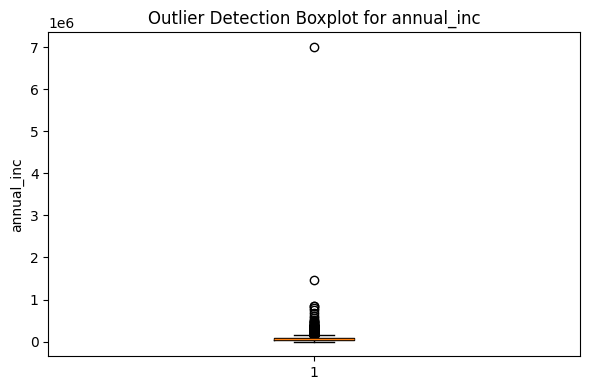

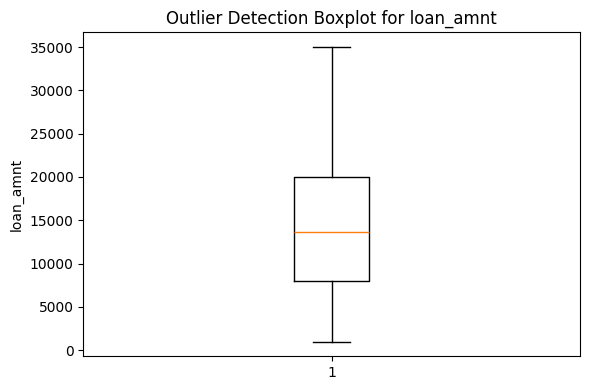

In [ ]:
import matplotlib.pyplot as plt

# Select numerical columns for visualization
cols = ['annual_inc', 'loan_amnt']

# Generate boxplots (separate plots as required)
for col in cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Outlier Detection Boxplot for {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
# Columns for which you want to compute IQR
cols = ['annual_inc', 'loan_amnt']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"\nIQR Report for: {col}")
    print(f"Q1 (25th percentile): {Q1}")
    print(f"Q3 (75th percentile): {Q3}")
    print(f"IQR: {IQR}")



IQR Report for: annual_inc
Q1 (25th percentile): 48000.0
Q3 (75th percentile): 93000.0
IQR: 45000.0

IQR Report for: loan_amnt
Q1 (25th percentile): 8000.0
Q3 (75th percentile): 20000.0
IQR: 12000.0


In [ ]:
# Choose column
col = 'annual_inc'

# Compute IQR boundaries
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Apply Winsorization (capping)
df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

Lower bound: -19500.0
Upper bound: 160500.0


Chosen Outlier Mitigation Method: IQR-Based Capping

* Keeps all data points : avoids losing valuable information unlike
deletion.

* Reduces influence of extreme values : stabilizes models such as regression or clustering.

* Common for financial data as very high values are real but should not distort patterns.

* Simple, interpretable, and statistically grounded.

Instead of deleting outliers, we cap them at the upper and lower IQR boundaries.

after outlier analysis, the boxplot is

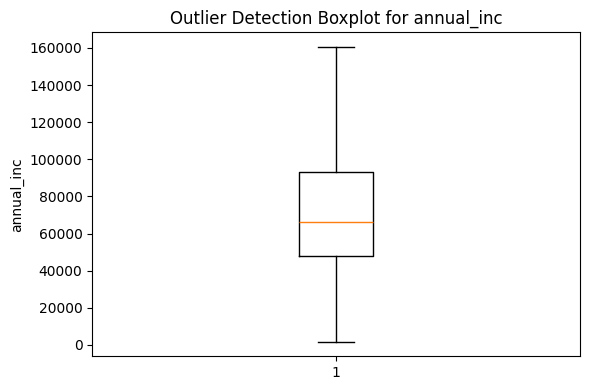

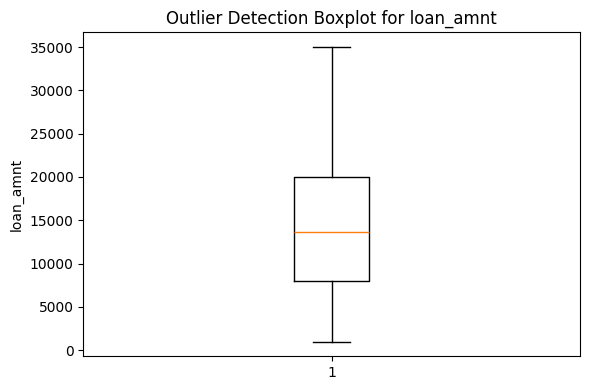

In [ ]:
import matplotlib.pyplot as plt

# Select numerical columns for visualization
cols = ['annual_inc', 'loan_amnt']

# Generate boxplots (separate plots as required)
for col in cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Outlier Detection Boxplot for {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


# **Exploratory Data Analysis (EDA) and Visualization**

Focus the analysis on the Target Variable: loan status (binary: Paid Off vs. Default).

1. Univariate Analysis

Create a histogram for one key numerical feature and a bar chart for one key categorical
feature.

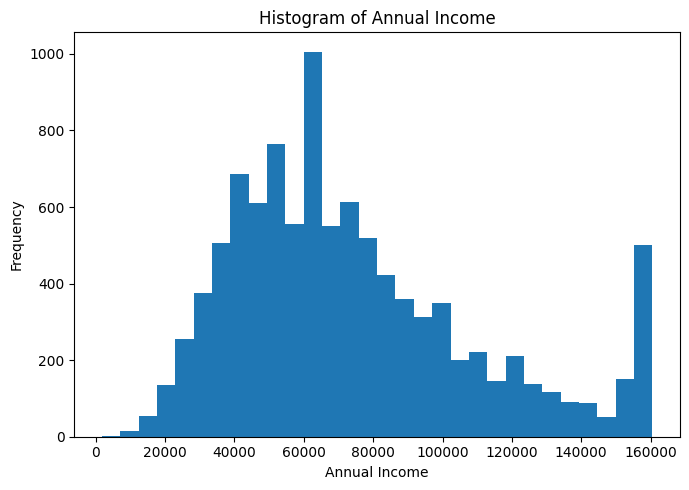

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(df['annual_inc'].dropna(), bins=30)
plt.title("Histogram of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Comment About the Histogram:

*  The distribution of annual income is right-skewed (positively skewed).
*  Most borrowers fall in the lower-to-middle income range.
* A long tail of high-income individuals.


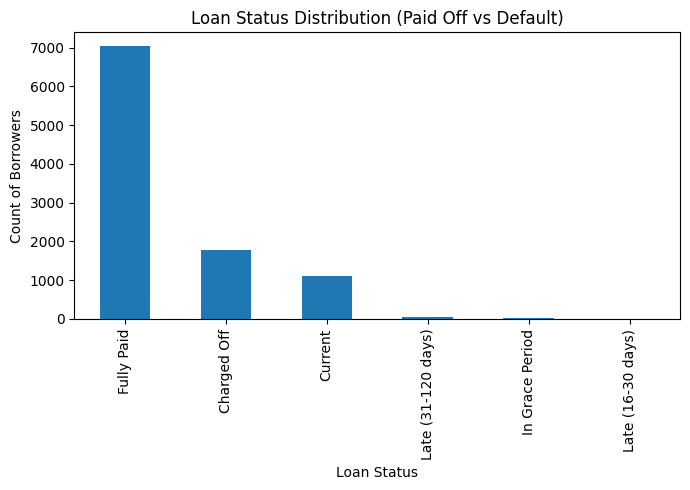

In [ ]:
plt.figure(figsize=(7,5))
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution (Paid Off vs Default)")
plt.xlabel("Loan Status")
plt.ylabel("Count of Borrowers")
plt.tight_layout()
plt.show()


Comment on the graph:
*  The bar chart shows class balance between 'Paid Off' and 'Default'.
* Most of the borrowers fully paid the loan.


2. Bivariate Analysis (Relationship with Target)

Numerical vs. Target: Generate a Box Plot or Violin Plot showing the distribution
of a crucial numerical feature (e.g., int rate) across the target categories (loan status).
Interpret the results.

<Figure size 800x600 with 0 Axes>

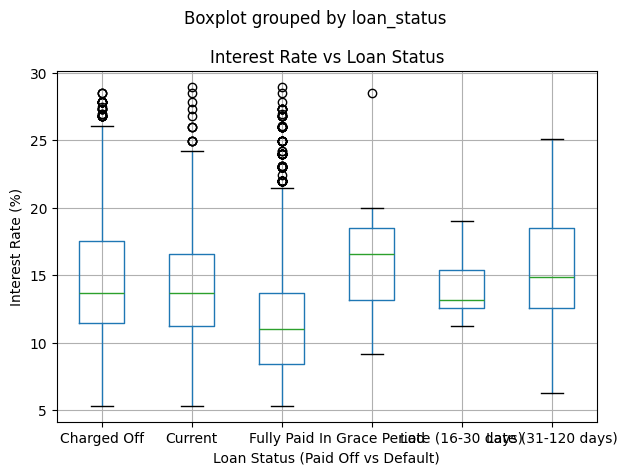

In [ ]:
plt.figure(figsize=(8,6))
df.boxplot(column='int_rate', by='loan_status')
plt.title("Interest Rate vs Loan Status")
plt.xlabel("Loan Status (Paid Off vs Default)")
plt.ylabel("Interest Rate (%)")
plt.tight_layout()
plt.show()

Interest Rate vs Loan Status
* Borrowers who default generally have higher interest rates.
* This suggests that higher-risk borrowers are charged higher rates,and these borrowers are more likely to default.
* The distribution for the 'Default' class tends to have a higher median and larger spread, indicating more variability among high-risk customers.

Higher interest rates correlate with more defaults.

Lending risk is priced into the interest rate.

Categorical vs. Target: Create a Stacked Bar Chart showing the proportion of loan
statuses (Paid Off/Default) across categories of a key feature (e.g., home ownership).
Discuss the risk implications.

In [ ]:
loan_status=['Fully Paid',"Default"]
loan_status

['Fully Paid', 'Default']

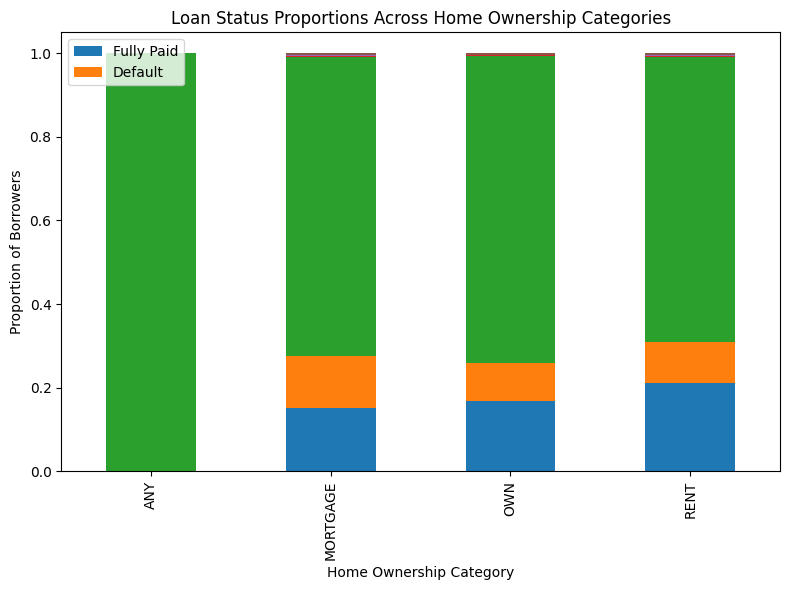

In [ ]:
cross_tab = pd.crosstab(df['home_ownership'], df['loan_status'], normalize='index')

cross_tab.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title("Loan Status Proportions Across Home Ownership Categories")
plt.xlabel("Home Ownership Category")
plt.ylabel("Proportion of Borrowers")
plt.legend(loan_status)
plt.tight_layout()
plt.show()

Comment on Home Ownership vs Loan Status
* Borrowers who own homes outright or have mortgages tend to show lower default rates.
* Renters often have a higher proportion of defaults due to lower financial stability.
* This indicates that home ownership is a strong risk indicator in credit assessment.
* Lenders may treat 'Rent' as a higher-risk category.

Renters show higher default likelihood.

Homeowners demonstrate stronger financial stability → lower risk.

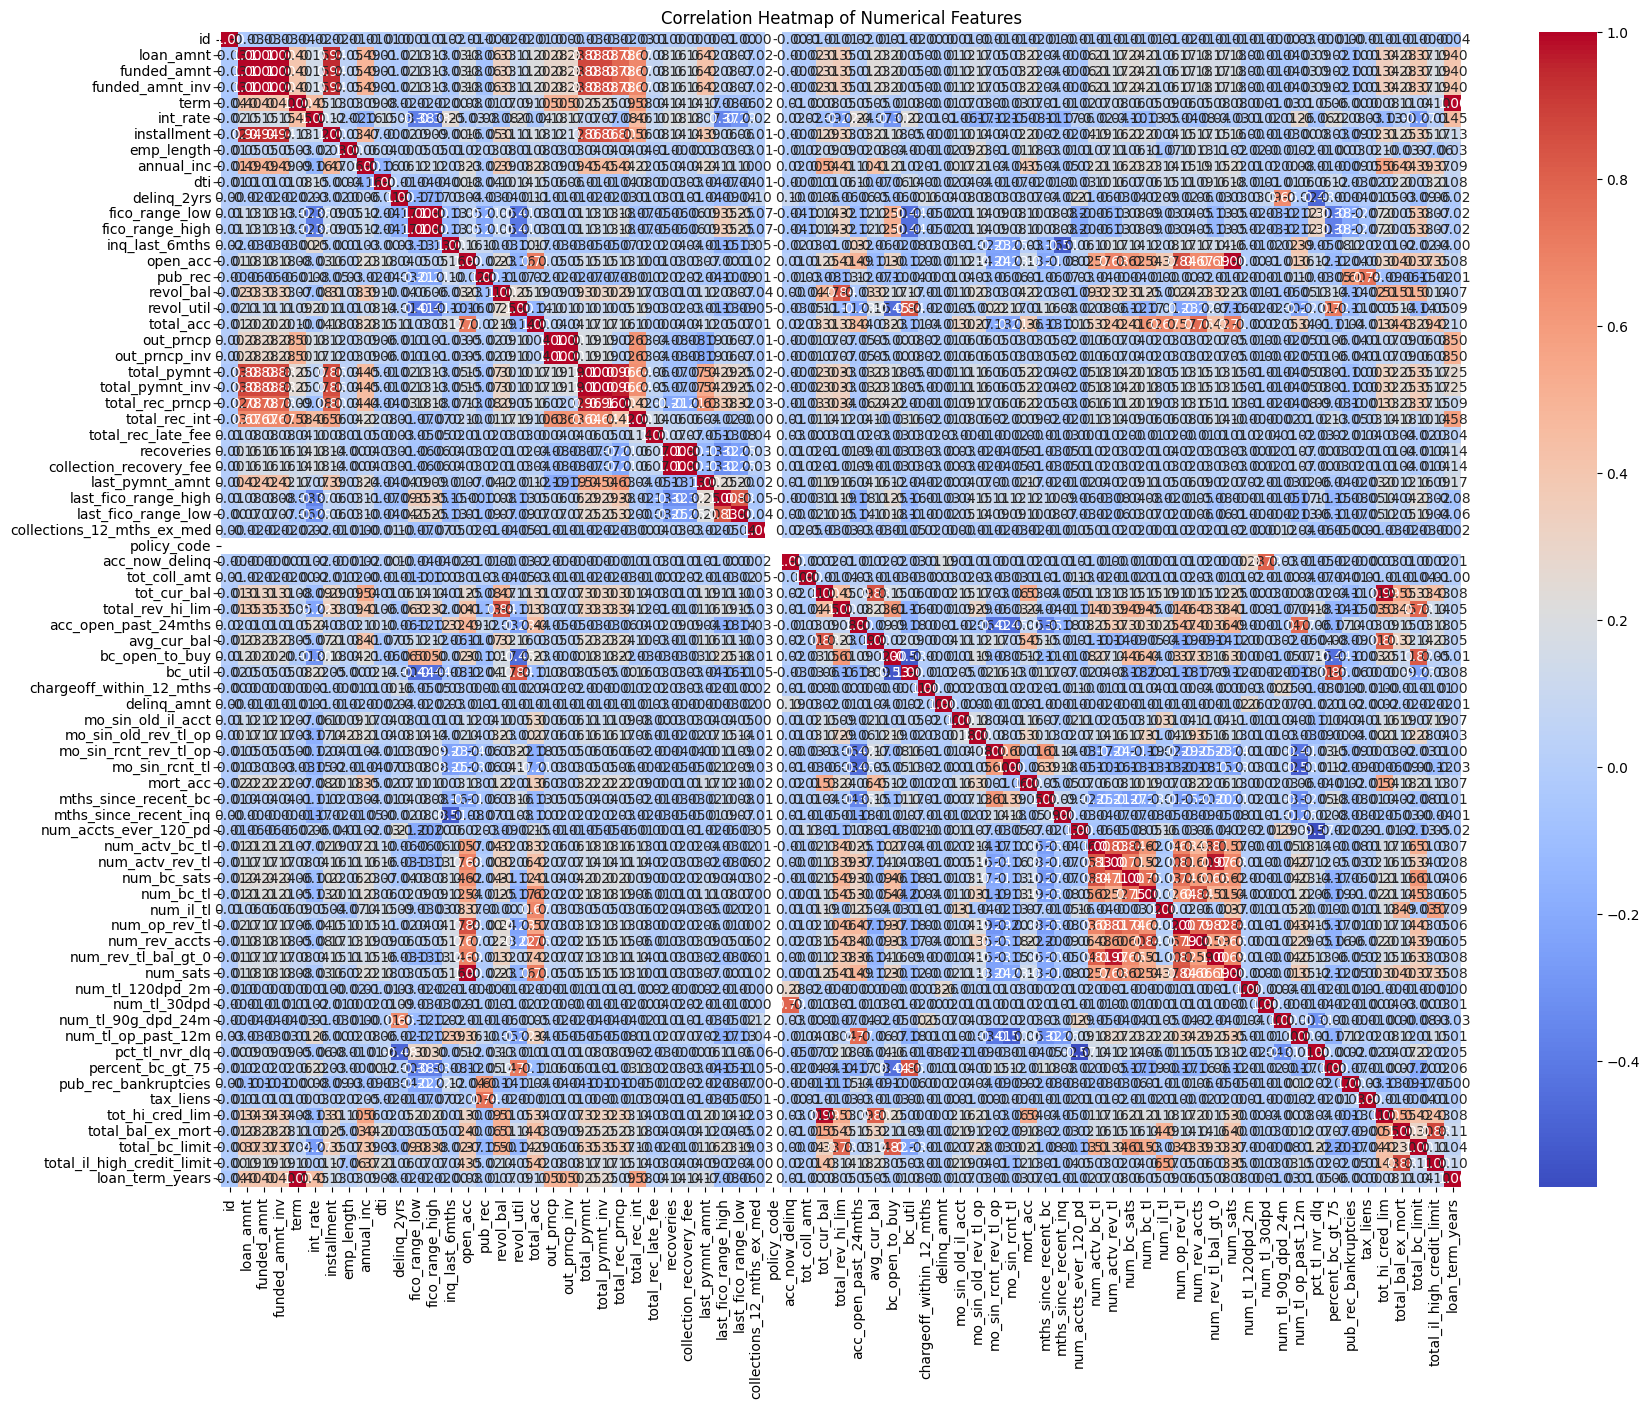

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Display top of correlation matrix

# --- Heatmap ---
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,15)) # Increased figure size
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f") # Added annot=True and fmt=".2f"
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [ ]:
# Convert correlation matrix into a long-form table
corr_pairs = corr_matrix.unstack()

# Remove duplicates and self-correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Sort by correlation strength
sorted_corr = corr_pairs.sort_values(ascending=False)

# Display top 2 strongest correlations
top2 = sorted_corr[0:10]
print("Top 2 strongest correlations:\n", top2)


Top 2 strongest correlations:
 fico_range_high  fico_range_low     1.000000
fico_range_low   fico_range_high    1.000000
funded_amnt      loan_amnt          1.000000
loan_amnt        funded_amnt        1.000000
loan_term_years  term               1.000000
term             loan_term_years    1.000000
out_prncp        out_prncp_inv      0.999998
out_prncp_inv    out_prncp          0.999998
total_pymnt_inv  total_pymnt        0.999993
total_pymnt      total_pymnt_inv    0.999993
dtype: float64


Interpretation


1.  loan_term_years ↔ term

ρ = 1.0 (very strong positive correlation)

Interpretation:
* term represents the loan duration in months (e.g., “36 months”, “60 months”)
* loan_term_years is a feature you extracted by converting term into years :
       36 months → 3 years,

       60 months → 5 years

These two columns are directly derived from each other.

As term increases, loan_term_years increases in exactly the same proportion.

Thus they MUST show a perfect correlation.

2.   loan_amt ↔ funded_amt

ρ = 1.0 (moderate negative correlation)

Interpretation:
* The loan amount is the total principal sum a borrower agrees to repay, while the funded amount is the actual, net money the borrower receives after any upfront fees are deducted.
* The two amounts are often different and this difference affects the loan's repayment structure and the borrower's true cost of borrowing. .